# 12 — Cooperación 2v1 y pase

Cuarta tarea del catálogo, con cinemática simple (sin física, observación completa). Código: `src/passing_env.py`
(entorno, heurística de referencia, representaciones), `src/task_train.py` y `src/task_analysis.py`.

**MDP** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, R, \gamma \rangle$:

- **Zona:** $30 \times 20$ m centrada en el origen. El agente controla al atacante que tiene el balón; el compañero
  y el defensor son guionados.
- **Inicio:** poseedor en los $24 \times 14$ m interiores con rumbo al azar; compañero a 6–10 m y defensor a 4–8 m del
  poseedor, dentro de la zona.
- **Acciones (4):** `PASE` (se resuelve en el paso; si la línea está bloqueada —defensor a < 1.5 m del segmento— se
  intercepta con prob. 0.8; si se completa, el receptor pasa a ser el poseedor, mirando en la dirección del pase),
  `DRIBLE` (+1 m en su rumbo), `GIRAR` (35° alejándose del defensor; si el defensor ya está a menos de 35° de
  quedar justo detrás, gira hacia el centro de la zona) y `DESPEJE` (termina con recompensa 0).
- **Transición:** tras la acción, el compañero avanza hasta 0.6 m hacia su punto de apoyo (8 m del poseedor, a
  ±60° de la dirección defensor→poseedor, del lado del compañero); el defensor avanza 0.6 m hacia el poseedor con
  ruido de rumbo $\mathcal{N}(0, 15^\circ)$. Si el poseedor sale de la zona: −10 y fin; si el defensor queda a
  < 1 m: quite con prob. 0.5 (−30 y fin).
- **Recompensa:** +30 por pase completado, −30 por intercepción o quite, −10 por salir de la zona.
- **$\gamma = 0.99$**, $T_{max} = 60$.
- **Estados (324):** $d_{comp}$ {< 5, 5–10, ≥ 10} m × $\theta_{comp}$ {frente ±45°, lado, atrás} × $d_{def}$
  {< 2, 2–5, ≥ 5} m × $\theta_{def}$ {frente, lado, atrás} × línea de pase {libre, bloqueada} × zona {banda (< 3 m
  de un borde), centro}. Los rumbos son relativos al poseedor; el bit de línea bloqueada resume lo que decide el
  riesgo de intercepción.
- **Criterio:** posesión > 50 pasos y ≥ 3 pases.

Con la recompensa del enunciado, un pase con la línea libre no tiene riesgo de intercepción y vale +30, así que
podría esperarse que pasar siempre con la línea libre sea lo mejor; la política aprendida no lo hace siempre (§4).
No hay cota exacta (estado continuo y estocástico); la heurística de §1 es una **referencia**, no una cota.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots, passing_env as pe
from src.task_analysis import load_condition
from src.task_train import get_task, run_episode
from src.agents import AGENTS

ART = "notebooks/artifacts"
RUNS = f"{ART}/runs_passing"
DIAG = f"{ART}/runs_passing_diag"
summary = json.load(open(f"{ART}/passing_summary.json"))["conditions"]
alphas = json.load(open(f"{ART}/passing_alphas.json"))
disc = pe.default_discretizer()
spec = get_task("passing")
METHOD_ES = {"qlearning": "Q-Learning", "sarsa": "SARSA", "mc_first_visit": "MC (promedio)",
             "mc_first_visit_alpha": "MC (α constante)"}
COLS = ["qlearning", "sarsa", "mc_first_visit_alpha", "mc_first_visit"]
SCHED_ES = {"eps_const_0.1": "ε const. 0.1", "eps_decay_1_to_0.1": "ε decreciente 1→0.1"}
def pct(x): return f"{100 * x:.1f} %"
def ci(s): return f"{pct(s['mean'])} [{100 * s['ci95'][0]:.1f}, {100 * s['ci95'][1]:.1f}]"

## 1. Referencias sin aprendizaje

Sobre los 500 inicios de evaluación, con el mismo ruido: política aleatoria, "pasar siempre" y una heurística
("pasar si la línea está libre; si no, girar si el defensor está adelante o cerca del borde, y driblar si está
atrás").

In [2]:
def rollout(policy, starts, seed=12345):
    env = pe.PassingEnv(seed=seed); rng = np.random.default_rng(0); out = []
    for s in starts:
        obs, info = env.reset(s); done = False
        while not done:
            obs, r, term, trunc, info = env.step(policy(obs, rng)); done = term or trunc
        out.append(info)
    return out
starts = pe.evaluation_starts(500, 12345)
refs = {"aleatoria": lambda o, r: int(r.integers(4)), "pasar siempre": lambda o, r: pe.PASE,
        "heurística": lambda o, r: pe.heuristic_action(o)}
rows, saved = ["| política | éxito | pases | posesión (pasos) | quite | intercepción | fuera | despeje |",
               "|---|---|---|---|---|---|---|---|"], {}
for name, pol in refs.items():
    res = rollout(pol, starts)
    oc = np.array([i["outcome"] for i in res])
    saved[name] = {"success_rate": float(np.mean([i["success"] for i in res])),
                   "mean_passes": float(np.mean([i["passes"] for i in res])),
                   "mean_possession": float(np.mean([i["possession"] for i in res])),
                   **{k: float(np.mean(oc == v)) for k, v in (("tackled", pe.TACKLED), ("intercepted", pe.INTERCEPTED),
                                                               ("out", pe.OUT), ("cleared", pe.CLEARED))}}
    s = saved[name]
    rows.append(f"| {name} | {pct(s['success_rate'])} | {s['mean_passes']:.1f} | {s['mean_possession']:.1f} | "
                f"{pct(s['tackled'])} | {pct(s['intercepted'])} | {pct(s['out'])} | {pct(s['cleared'])} |")
json.dump(saved, open(f"{ART}/passing_references.json", "w"), indent=2, ensure_ascii=False)
display(Markdown("\n".join(rows)))

| política | éxito | pases | posesión (pasos) | quite | intercepción | fuera | despeje |
|---|---|---|---|---|---|---|---|
| aleatoria | 0.0 % | 0.8 | 2.6 | 1.6 % | 4.0 % | 1.6 % | 92.8 % |
| pasar siempre | 0.0 % | 15.8 | 15.8 | 2.6 % | 97.4 % | 0.0 % | 0.0 % |
| heurística | 10.8 % | 18.1 | 28.1 | 94.6 % | 0.0 % | 0.0 % | 0.0 % |

## 2. Ablación de exploración (Q-Learning)

Q-Learning, 60 000 episodios, 5 semillas (0–4), $\alpha$ elegido por separado para cada exploración con un barrido
en semillas 5–9. Evaluación greedy cada 2 000 episodios sobre 500 inicios fijos con el mismo ruido. Curvas: media
de 5 semillas; banda: mínimo–máximo entre semillas.

α elegidos (barrido por esquema, semillas 5–9):
  mc_first_visit_alpha|eps_const_0.1: 0.03
  mc_first_visit_alpha|eps_decay_1_to_0.1: 0.03
  qlearning|eps_const_0.1: 0.03
  qlearning|eps_decay_1_to_0.1: 0.03
  sarsa|eps_const_0.1: 0.03
  sarsa|eps_decay_1_to_0.1: 0.03


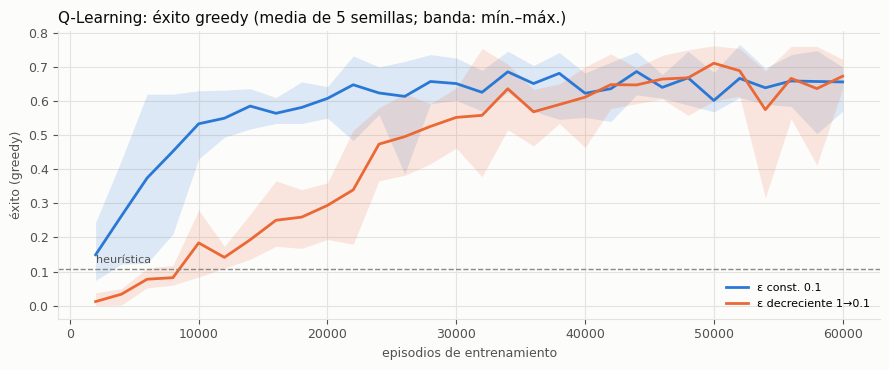

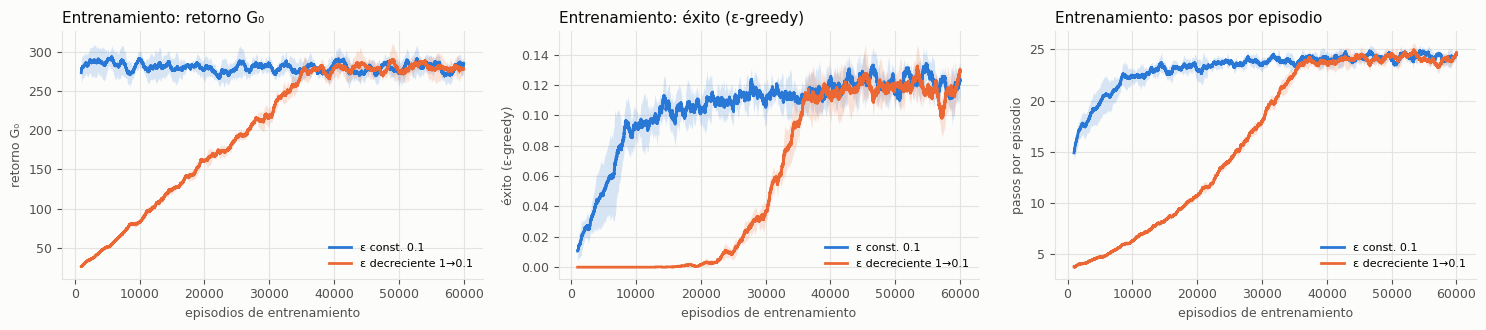

In [3]:
print("α elegidos (barrido por esquema, semillas 5–9):")
for k, v in sorted(alphas["alphas"].items()):
    if "|" in k: print(f"  {k}: {v:g}")
q_runs = {c: load_condition(f"{RUNS}/passing_qlearning_{c}") for c in ("eps_const_0.1", "eps_decay_1_to_0.1")}
href = json.load(open(f"{ART}/passing_references.json"))["heurística"]["success_rate"]
fig, ax = plt.subplots(figsize=(9, 3.8))
plots.plot_task_eval_curves(q_runs, "default", ax=ax, labels=SCHED_ES, ylabel="éxito (greedy)",
                            refs={"heurística": href}, title="Q-Learning: éxito greedy (media de 5 semillas; banda: mín.–máx.)")
fig.tight_layout(); fig.savefig(f"{ART}/fig_passing_ablation.png", dpi=150, bbox_inches="tight"); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, key, ylab in zip(axes, ("discounted_return", "success", "steps"),
                         ("retorno G₀", "éxito (ε-greedy)", "pasos por episodio")):
    plots.plot_training_curve(q_runs, key, window=1000, ax=ax, labels=SCHED_ES, ylabel=ylab,
                              title=f"Entrenamiento: {ylab}", direct_labels=False)
fig.tight_layout(); fig.savefig(f"{ART}/fig_passing_training.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Cómo termina cada episodio

Resultado de la política greedy final (media de 5 semillas) frente a la heurística.

In [4]:
rows = ["| política | éxito | pases | posesión | quite | intercepción | fuera | despeje |", "|---|---|---|---|---|---|---|---|"]
for c, rs in q_runs.items():
    last = [r["final_eval"]["variants"]["default"] for r in rs]
    m = lambda k: np.mean([l[k] for l in last])
    rows.append(f"| Q-Learning, {SCHED_ES[c]} | {pct(m('success_rate'))} | {m('mean_passes'):.1f} | {m('mean_possession'):.1f} | "
                f"{pct(m('tackled_rate'))} | {pct(m('intercepted_rate'))} | {pct(m('out_rate'))} | {pct(m('cleared_rate'))} |")
h = json.load(open(f"{ART}/passing_references.json"))["heurística"]
rows.append(f"| heurística | {pct(h['success_rate'])} | {h['mean_passes']:.1f} | {h['mean_possession']:.1f} | "
            f"{pct(h['tackled'])} | {pct(h['intercepted'])} | {pct(h['out'])} | {pct(h['cleared'])} |")
display(Markdown("\n".join(rows)))

| política | éxito | pases | posesión | quite | intercepción | fuera | despeje |
|---|---|---|---|---|---|---|---|
| Q-Learning, ε const. 0.1 | 65.6 % | 21.7 | 47.9 | 13.4 % | 0.1 % | 23.4 % | 0.0 % |
| Q-Learning, ε decreciente 1→0.1 | 67.3 % | 19.3 | 48.7 | 10.8 % | 0.2 % | 24.0 % | 0.0 % |
| heurística | 10.8 % | 18.1 | 28.1 | 94.6 % | 0.0 % | 0.0 % | 0.0 % |

## 4. Política aprendida

Q-Learning con $\varepsilon$ decreciente, semilla 0: fracción de estados visitados (evaluación final) en los que la
acción greedy es cada una, separando línea libre y bloqueada.

In [5]:
Q = q_runs["eps_decay_1_to_0.1"][0]["Q"]
env = pe.PassingEnv(seed=12345); agent = AGENTS["qlearning"](disc.n_states, 4, seed=0); agent.Q = Q.copy()
visits = np.zeros(disc.n_states, dtype=int)
for s in starts:
    obs, _ = env.reset(s); done = False
    while not done:
        st = disc(obs); visits[st] += 1
        obs, r, term, trunc, info = env.step(int(np.argmax(Q[st]))); done = term or trunc
rows = ["| línea de pase | estados visitados | " + " | ".join(pe.ACTION_NAMES) + " |", "|---|---|---|---|---|---|"]
for b, name in ((0, "libre"), (1, "bloqueada")):
    sts = [s for s in range(disc.n_states) if visits[s] > 0 and disc.decompose(s)[4] == b]
    acts = np.bincount(Q[sts].argmax(1), minlength=4) / max(1, len(sts))
    w = np.bincount(Q[sts].argmax(1), weights=visits[sts], minlength=4) / max(1, visits[sts].sum())
    rows.append(f"| {name} | {len(sts)} | " + " | ".join(f"{pct(a)} ({pct(x)} de las visitas)" for a, x in zip(acts, w)) + " |")
display(Markdown("\n".join(rows)))

| línea de pase | estados visitados | PASE | DRIBLE | GIRAR | DESPEJE |
|---|---|---|---|---|---|
| libre | 62 | 66.1 % (49.8 % de las visitas) | 21.0 % (18.3 % de las visitas) | 12.9 % (32.0 % de las visitas) | 0.0 % (0.0 % de las visitas) |
| bloqueada | 54 | 0.0 % (0.0 % de las visitas) | 59.3 % (65.4 % de las visitas) | 40.7 % (34.6 % de las visitas) | 0.0 % (0.0 % de las visitas) |

## 5. Trayectorias mientras aprende

Política greedy de copias de la Q-table (Q-Learning, $\varepsilon$ decreciente, semilla 0) sobre el primer inicio de
evaluación (elegido por regla, no por su resultado).
Línea de color: balón (los pases son saltos rectos; puntos: recepciones); punteado gris: defensor.

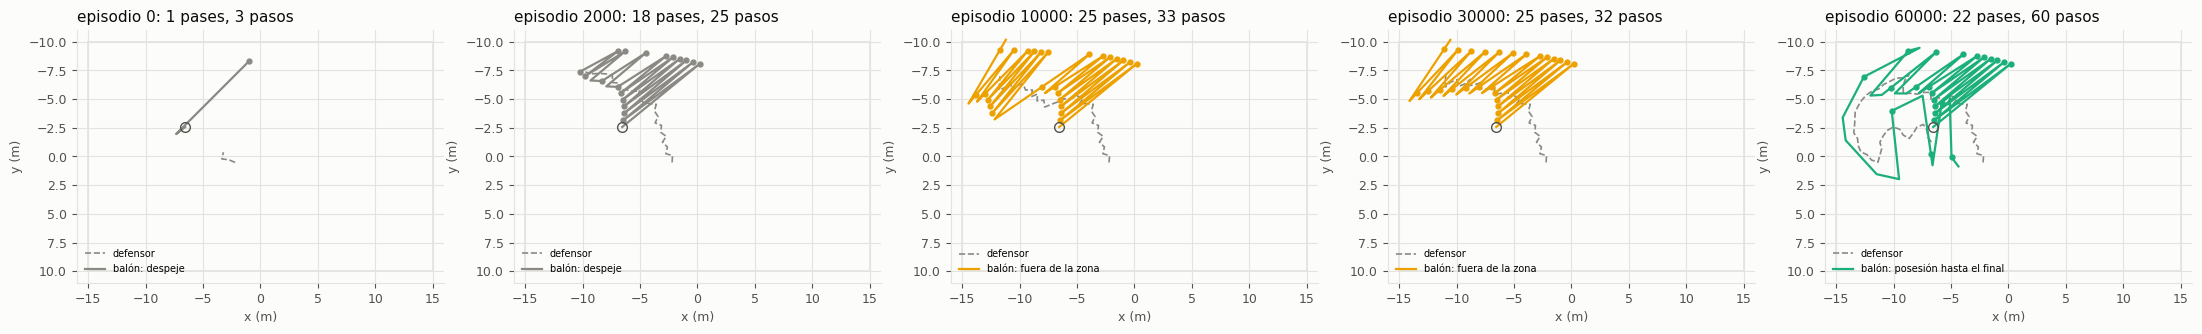

In [6]:
snaps = np.load(f"{RUNS}/passing_qlearning_eps_decay_1_to_0.1/seed_0/q_snapshots.npz")
keys = sorted(snaps.files, key=lambda k: int(k.split("_")[1]))
start = starts[0]
fig, axes = plt.subplots(1, len(keys), figsize=(4.4 * len(keys), 3.6))
for ax, k in zip(axes, keys):
    agent = AGENTS["qlearning"](disc.n_states, 4, seed=0); agent.Q = snaps[k].copy()
    env.rng = np.random.default_rng(5)
    rec = run_episode(spec, env, agent, disc, 0.0, learn=False, start=start, record=True)
    plots.plot_passing_episode(rec, ax=ax, title=f"episodio {int(k.split('_')[1])}: {rec['passes']} pases, "
                               f"{rec['possession']} pasos")
fig.tight_layout(); fig.savefig(f"{ART}/fig_passing_learning_traj.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Criterio de éxito

Éxito greedy: final, media de las últimas 5 evaluaciones y peor de las últimas 5 (media de 5 semillas, IC 95 %
bootstrap). Criterio: posesión > 50 pasos y ≥ 3 pases.

In [7]:
rows = ["| método | exploración | α | final | media últimas 5 | peor de últimas 5 |", "|---|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    v = s["variants"]["default"]
    alpha = "1/N" if s["algorithm"] == "mc_first_visit" else f"{s['alpha']:g}"
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {SCHED_ES['eps_' + name.split('_eps_')[1]]} | {alpha} | "
                f"{ci(v['final'])} | {ci(v['last5_mean'])} | {ci(v['last5_worst'])} |")
display(Markdown("\n".join(rows)))

| método | exploración | α | final | media últimas 5 | peor de últimas 5 |
|---|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 0.03 | 20.8 % [8.3, 33.4] | 16.7 % [6.8, 27.6] | 10.7 % [3.9, 21.0] |
| MC (α constante) | ε decreciente 1→0.1 | 0.03 | 22.1 % [8.0, 36.4] | 20.7 % [9.8, 31.5] | 12.1 % [6.5, 18.9] |
| MC (promedio) | ε const. 0.1 | 1/N | 25.0 % [17.2, 38.7] | 26.1 % [18.0, 39.9] | 24.6 % [16.6, 38.2] |
| MC (promedio) | ε decreciente 1→0.1 | 1/N | 8.6 % [3.4, 16.0] | 7.8 % [2.9, 14.9] | 6.6 % [2.2, 13.5] |
| Q-Learning | ε const. 0.1 | 0.03 | 65.6 % [60.6, 69.7] | 65.5 % [64.2, 67.4] | 58.3 % [53.8, 61.9] |
| Q-Learning | ε decreciente 1→0.1 | 0.03 | 67.3 % [65.0, 70.0] | 64.8 % [61.3, 68.1] | 52.2 % [39.6, 63.4] |
| SARSA | ε const. 0.1 | 0.03 | 55.4 % [50.0, 60.4] | 54.2 % [51.9, 56.3] | 41.3 % [32.3, 48.0] |
| SARSA | ε decreciente 1→0.1 | 0.03 | 58.4 % [47.5, 67.6] | 54.2 % [51.0, 56.1] | 45.2 % [41.2, 49.2] |

## 7. Comparación de métodos

AUC = media del éxito greedy a lo largo del entrenamiento (mayor = aprende antes). $\varepsilon$-greedy = éxito del
último 10 % del entrenamiento, con la exploración activa; pérdidas = quites + intercepciones + salidas en ese tramo.

| método | exploración | media últimas 5 | AUC | ε-greedy (último 10 %) | pérdidas ε-greedy |
|---|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 16.7 % [6.8, 27.6] | 10.1 % [6.4, 14.0] | 3.2 % [1.5, 4.9] | 19.6 % |
| MC (α constante) | ε decreciente 1→0.1 | 20.7 % [9.8, 31.5] | 9.2 % [4.8, 14.2] | 3.6 % [1.9, 5.3] | 22.6 % |
| MC (promedio) | ε const. 0.1 | 26.1 % [18.0, 39.9] | 18.1 % [10.7, 29.7] | 4.4 % [3.1, 6.8] | 31.9 % |
| MC (promedio) | ε decreciente 1→0.1 | 7.8 % [2.9, 14.9] | 2.6 % [1.5, 3.6] | 1.2 % [0.5, 2.1] | 16.7 % |
| Q-Learning | ε const. 0.1 | 65.5 % [64.2, 67.4] | 58.8 % [57.8, 60.1] | 12.1 % [11.6, 12.6] | 30.6 % |
| Q-Learning | ε decreciente 1→0.1 | 64.8 % [61.3, 68.1] | 44.9 % [42.5, 46.5] | 11.6 % [11.4, 11.8] | 31.7 % |
| SARSA | ε const. 0.1 | 54.2 % [51.9, 56.3] | 47.2 % [44.8, 49.5] | 8.6 % [8.1, 9.2] | 38.6 % |
| SARSA | ε decreciente 1→0.1 | 54.2 % [51.0, 56.1] | 28.2 % [25.3, 30.2] | 8.3 % [7.8, 8.7] | 39.7 % |

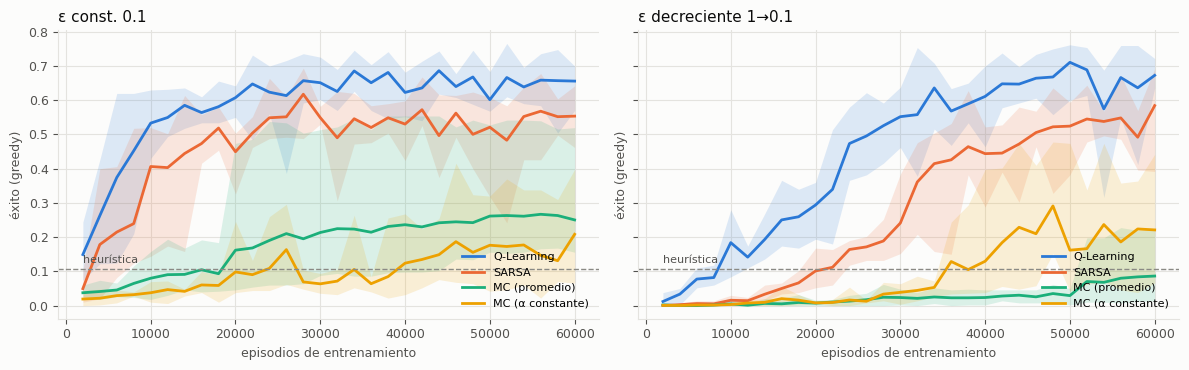

In [8]:
def online(path, n):
    runs = load_condition(path); tail = n // 10
    return np.mean([np.isin(r["history"]["outcome"][-tail:], [pe.TACKLED, pe.INTERCEPTED, pe.OUT]).mean() for r in runs])
rows = ["| método | exploración | media últimas 5 | AUC | ε-greedy (último 10 %) | pérdidas ε-greedy |",
        "|---|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    v = s["variants"]["default"]
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {SCHED_ES['eps_' + name.split('_eps_')[1]]} | {ci(v['last5_mean'])} | "
                f"{ci(v['auc'])} | {ci(s['online_final'])} | {pct(online(f'{RUNS}/{name}', s['n_episodes']))} |")
display(Markdown("\n".join(rows)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, sched in zip(axes, ("eps_const_0.1", "eps_decay_1_to_0.1")):
    runs = {m: load_condition(f"{RUNS}/passing_{m}_{sched}") for m in METHOD_ES}
    plots.plot_task_eval_curves(runs, "default", ax=ax, labels=METHOD_ES, ylabel="éxito (greedy)",
                                refs={"heurística": href}, title=SCHED_ES[sched])
fig.tight_layout(); fig.savefig(f"{ART}/fig_passing_methods.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Diagnósticos

**Representación.** Parte de los episodios termina fuera de la zona (§3): la representación solo dice "cerca de un
borde", no hacia dónde queda. La representación fina (1 944 estados) agrega el rumbo al centro de la zona
y zonas más finas de distancia al defensor y al borde. Ambas con 120 000 episodios, $\varepsilon$ decreciente.

**Riesgo.** Con $\varepsilon$ constante, los métodos on-policy aprenden el valor de la política que explora y
deberían evitar más los quites que Q-Learning si el riesgo importa. Si es así, la diferencia de pérdidas durante la
exploración entre SARSA y Q-Learning debería crecer con la probabilidad de quite (0.2, 0.5, 0.8).

**Representación (120 000 episodios, ε decreciente):**

| método | 324 estados: media últ. 5 | peor últ. 5 | 1 944 estados: media últ. 5 | peor últ. 5 |
|---|---|---|---|---|
| Q-Learning | 67.9 % [65.7, 69.4] | 62.0 % [58.6, 65.4] | 62.4 % [59.5, 64.9] | 57.8 % [53.7, 61.1] |
| SARSA | 52.3 % [50.6, 54.3] | 40.3 % [36.0, 44.5] | 45.9 % [42.9, 48.5] | 39.0 % [33.3, 44.3] |
| MC (α constante) | 24.4 % [19.5, 30.1] | 14.2 % [6.2, 22.1] | 15.3 % [14.6, 16.3] | 9.6 % [8.3, 11.0] |
| MC (promedio) | 9.4 % [4.6, 13.7] | 8.0 % [4.2, 11.4] | 7.5 % [4.6, 10.4] | 6.0 % [3.2, 8.9] |

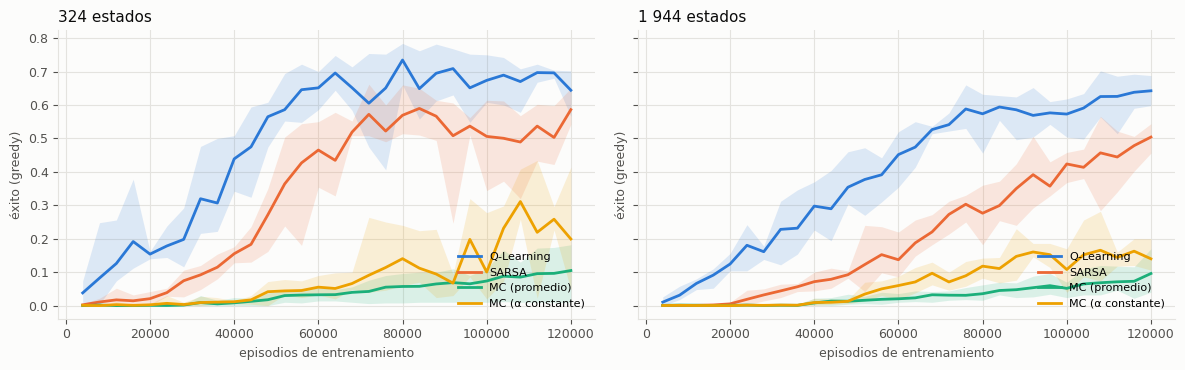

**Riesgo (ε constante 0.1, último 10 % del entrenamiento):**

| método | pérdidas ε-greedy, quite 0.2 | 0.5 | 0.8 | éxito ε-greedy 0.2 | 0.5 | 0.8 |
|---|---|---|---|---|---|---|
| Q-Learning | 29.2 % | 30.6 % | 31.4 % | 12.4 % [12.0, 12.8] | 12.1 % [11.6, 12.6] | 11.6 % [11.1, 12.1] |
| SARSA | 39.0 % | 38.6 % | 38.2 % | 8.4 % [7.7, 9.0] | 8.6 % [8.1, 9.2] | 8.3 % [8.1, 8.6] |
| MC (α constante) | 29.9 % | 19.6 % | 18.0 % | 7.2 % [5.7, 8.5] | 3.2 % [1.5, 4.9] | 2.1 % [1.4, 3.1] |
| MC (promedio) | 34.4 % | 31.9 % | 26.5 % | 4.6 % [2.3, 8.6] | 4.4 % [3.1, 6.8] | 3.2 % [2.0, 5.3] |

In [9]:
def row(name):
    x = summary[name]["variants"]["default"]
    return f"{ci(x['last5_mean'])} | {ci(x['last5_worst'])}"
rows = ["| método | 324 estados: media últ. 5 | peor últ. 5 | 1 944 estados: media últ. 5 | peor últ. 5 |", "|---|---|---|---|---|"]
for m in COLS:
    rows.append(f"| {METHOD_ES[m]} | {row(f'passing_diag_rep_default_{m}')} | {row(f'passing_diag_rep_fine_{m}')} |")
display(Markdown("**Representación (120 000 episodios, ε decreciente):**\n\n" + "\n".join(rows)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, rep, title in zip(axes, ("default", "fine"), ("324 estados", "1 944 estados")):
    runs = {m: load_condition(f"{DIAG}/passing_diag_rep_{rep}_{m}") for m in METHOD_ES}
    plots.plot_task_eval_curves(runs, "default", ax=ax, labels=METHOD_ES, ylabel="éxito (greedy)", title=title)
fig.tight_layout(); fig.savefig(f"{ART}/fig_passing_representation.png", dpi=150, bbox_inches="tight"); plt.show()

rows = ["| método | pérdidas ε-greedy, quite 0.2 | 0.5 | 0.8 | éxito ε-greedy 0.2 | 0.5 | 0.8 |", "|---|---|---|---|---|---|---|"]
for m in COLS:
    paths = [(f"{DIAG}/passing_diag_tackle0.2_{m}", f"passing_diag_tackle0.2_{m}"),
             (f"{RUNS}/passing_{m}_eps_const_0.1", f"passing_{m}_eps_const_0.1"),
             (f"{DIAG}/passing_diag_tackle0.8_{m}", f"passing_diag_tackle0.8_{m}")]
    losses = [pct(online(p, summary[n]["n_episodes"])) for p, n in paths]
    succ = [ci(summary[n]["online_final"]) for _, n in paths]
    rows.append(f"| {METHOD_ES[m]} | " + " | ".join(losses + succ) + " |")
display(Markdown("**Riesgo (ε constante 0.1, último 10 % del entrenamiento):**\n\n" + "\n".join(rows)))

## Verificación en rcssserver

Ejecución de la política greedy (Q-Learning, ε decreciente, semilla 0) en el servidor real con
`python -m src.live_tasks passing --episodes 10`: tres clientes (dos atacantes y un defensor guionado). `PASE` es una
patada hacia el compañero con potencia según la distancia, `DRIBLE` es `kick 10` hacia adelante, `GIRAR` es
`turn ±35` con la regla del entorno y `DESPEJE` es `kick 100`. El estado se calcula con la verdad de terreno. En el
servidor un pase tarda varios ciclos en llegar (en el modelo es instantáneo), así que no esperamos que el éxito se
transfiera: es una verificación de ejecución.

In [10]:
live = json.load(open(f"{ART}/live_passing.json"))
display(Markdown(f"Ciclos perdidos: {live['missed_cycles']}. Resultados de {len(live['episodes'])} episodios: {live['outcomes']} "
                 f"(`out`: el balón sale de la zona; `defender_ball`: el defensor queda en posesión). Pases intentados por "
                 f"episodio: {live['mean_passes_attempted']:.1f}."))

Ciclos perdidos: 0. Resultados de 10 episodios: {'defender_ball': 3, 'out': 7} (`out`: el balón sale de la zona; `defender_ball`: el defensor queda en posesión). Pases intentados por episodio: 1.7.

## Figura para el informe

(a) Ablación de exploración de Q-Learning; (b) los cuatro métodos con $\varepsilon$ decreciente; (c) representación:
media (barra) y peor (marca) de las últimas 5 evaluaciones con 324 y 1 944 estados; (d) cómo terminan los 500 episodios
de evaluación con la política greedy final (media de 5 semillas) y con la heurística.

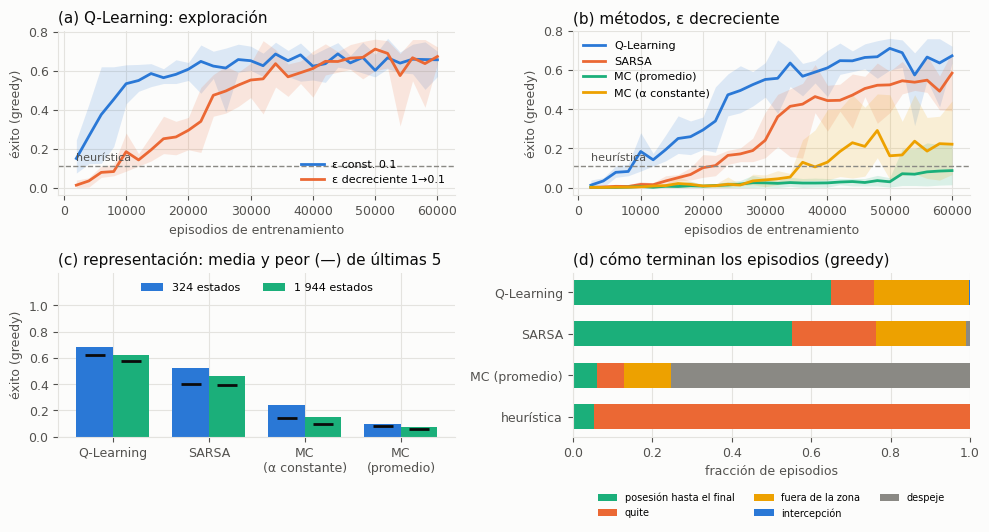

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
plots.plot_task_eval_curves(q_runs, "default", ax=axes[0, 0], labels=SCHED_ES, ylabel="éxito (greedy)",
                            refs={"heurística": href}, title="(a) Q-Learning: exploración")
runs = {m: load_condition(f"{RUNS}/passing_{m}_eps_decay_1_to_0.1") for m in METHOD_ES}
plots.plot_task_eval_curves(runs, "default", ax=axes[0, 1], labels=METHOD_ES, ylabel="éxito (greedy)",
                            refs={"heurística": href}, title="(b) métodos, ε decreciente")
axes[0, 1].legend(frameon=False, fontsize=8, loc="upper left")
ax = axes[1, 0]; w = 0.38
for j, (rep, name, color) in enumerate((("default", "324 estados", plots.SERIES[0]), ("fine", "1 944 estados", plots.SERIES[2]))):
    means = [summary[f"passing_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_mean"]["mean"] for m in COLS]
    worst = [summary[f"passing_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_worst"]["mean"] for m in COLS]
    xs = np.arange(len(COLS)) + (j - 0.5) * w
    ax.bar(xs, means, width=w, color=color, label=name)
    ax.plot(xs, worst, "_", color=plots.TEXT, markersize=14, markeredgewidth=2)
ax.set_xticks(range(len(COLS)), [METHOD_ES[m].replace(" (", "\n(") for m in COLS], fontsize=8)
plots.style(ax, "(c) representación: media y peor (—) de últimas 5", "", "éxito (greedy)")
ax.set_ylim(0, 1.25); ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.legend(frameon=False, fontsize=8, loc="upper center", ncol=2)
ax = axes[1, 1]
cats = [("full_possession_rate", "posesión hasta el final", "#1baf7a"), ("tackled_rate", "quite", "#eb6834"),
        ("out_rate", "fuera de la zona", "#eda100"), ("intercepted_rate", "intercepción", "#2a78d6"),
        ("cleared_rate", "despeje", "#8a8984")]
rows = {"Q-Learning": f"{RUNS}/passing_qlearning_eps_decay_1_to_0.1", "SARSA": f"{RUNS}/passing_sarsa_eps_decay_1_to_0.1",
        "MC (promedio)": f"{RUNS}/passing_mc_first_visit_eps_decay_1_to_0.1"}
vals = {name: [np.mean([r["final_eval"]["variants"]["default"][k] for r in load_condition(path)]) for k, _, _ in cats]
        for name, path in rows.items()}
hmap = {"full_possession_rate": 1 - h["tackled"] - h["intercepted"] - h["out"] - h["cleared"], "tackled_rate": h["tackled"],
        "out_rate": h["out"], "intercepted_rate": h["intercepted"], "cleared_rate": h["cleared"]}
vals["heurística"] = [hmap[k] for k, _, _ in cats]
names = list(vals)
left = np.zeros(len(names))
for j, (k, label, color) in enumerate(cats):
    w = np.array([vals[n][j] for n in names])
    ax.barh(range(len(names)), w, left=left, color=color, label=label, height=0.6)
    left += w
ax.set_yticks(range(len(names)), names, fontsize=8); ax.invert_yaxis(); ax.set_xlim(0, 1)
plots.style(ax, "(d) cómo terminan los episodios (greedy)", "fracción de episodios", "")
ax.legend(frameon=False, fontsize=7, loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=3)
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_passing.png", dpi=200, bbox_inches="tight"); plt.show()

## 9. Conclusiones

Todos los números están en las tablas de arriba (IC 95 % bootstrap sobre 5 semillas; una diferencia se declara
solo si los IC no se solapan).

- **Resultado:** Q-Learning cumple el criterio (posesión > 50 pasos y ≥ 3 pases) en el 65.5 % de los episodios
  (media de las últimas 5 evaluaciones, ε constante; 64.8 % con ε decreciente), frente al 10.8 % de la heurística. No
  hay cota exacta, así que no sabemos cuánto falta para el óptimo. Las fallas restantes son quites y salidas de la
  zona; las intercepciones son casi nulas: la política nunca pasa con la línea bloqueada.
- **La recompensa invita a pasar mucho:** la política da unos 20 pases por episodio, el doble de lo necesario para el
  criterio, porque cada pase con la línea libre vale +30 sin riesgo de intercepción. Aun así, con la línea libre no
  pasa siempre (≈ 50 % de las visitas en la semilla 0, §4); no aislamos por qué.
- **Exploración (Q-Learning):** al final no hay diferencia detectable (65.5 % frente a 64.8 %), pero ε constante
  aprende antes (AUC 58.8 % frente a 44.9 %). En SARSA, lo mismo (54.2 % con ambos; AUC 47.2 % frente a 28.2 %).
- **Métodos:** Q-Learning supera a SARSA con ambas exploraciones (IC separados), y los dos MC fallan (26.1 % o menos). MC con
  promedios y ε decreciente termina el 75 % de los episodios con un **despeje**: prefiere regalar el balón (0) a
  seguir. Es coherente con el paso 1/N, que conserva con peso completo los retornos malos de las políticas
  iniciales, pero no lo aislamos.
- **Riesgo (hipótesis H2): contradicha.** SARSA sufre *más* quites que Q-Learning durante la exploración (13.8 %
  frente a 8.7 % con probabilidad de quite 0.5), y la diferencia no crece con el riesgo (4.7, 5.1 y 5.6 puntos con
  0.2, 0.5 y 0.8). El éxito durante la exploración es bajo para todos (≤ 13 %) porque una acción aleatoria
  `DESPEJE` termina el episodio.
- **Representación:** la de 1 944 estados rinde *peor* que la de 324 con el mismo presupuesto (Q-Learning 62.4 %
  frente a 67.9 %; SARSA 45.9 % frente a 52.3 %; IC separados) y no reduce las salidas de la zona. La falta de
  información sobre hacia dónde queda el borde no es lo que limita; con este presupuesto no podemos separar
  "información insuficiente" de "más estados que datos".